# ACL_ICWSM_2018

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description

This datasets consist of tweets collected during the 2015 Nepal Earthquake and the 2013 Queensland Flood. The annotation of relevant and irrelevant (not_relevant) categories consist of 11,668 tweets for the Nepal Earthquake dataset and 10,033 tweets for the Queensland dataset.

For each dataset, we also release ids of the tweets of the unlabelled data that we used for our experiments. One can use our Tweet retrieval tool (available on CrisisNLP.qcri.org) to download the tweets based on ids provided in the datasets.

### Data formats
Each .tsv file contains 3 columns separated by tab:
1) id
2) text of the tweet
3) class label. The .txt file contains tweets ids, which are not labeled. 

##### 2015 Nepal Earthquake:
- nepal/2015_Nepal_Earthquake_train.tsv -- 7000 labeled tweets
- nepal/2015_Nepal_Earthquake_dev.tsv  -- 1166 labeled tweets
- nepal/2015_Nepal_Earthquake_test.tsv  -- 3502 labeled tweets
- nepal/2015_Nepal_Earthquake_unlabelled_ids.txt -- 864,966 un-labeled tweet ids


##### 2013 Queensland Flood:
- queensland/2013_Queensland_Floods_train.tsv -- 6019 labeled tweets 
- queensland/2013_Queensland_Floods_dev.tsv -- 1003 labeled tweets 
- queensland/2013_Queensland_Floods_test.tsv -- 3011 labeled tweets
- queensland/2013_Queensland_Floods_unlabelled_ids.txt -- 21,917  un-labeled tweet ids


### Citation information

- Firoj Alam, Shafiq Joty, Muhammad Imran. Domain Adaptation with Adversarial Training and Graph Embeddings. In proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (ACL), 2018, Melbourne, Australia. 

- Firoj Alam, Shafiq Joty, Muhammad Imran. Graph Based Semi-supervised Learning with Convolutional Neural Networks to Classify Crisis Related Tweets, International AAAI Conference on Web and Social Media (ICWSM), 2018, Stanford, California, USA.

## B. Overview

In [2]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'ACL_ICWSM_2018' / 'ACL_ICWSM_2018_datasets'

Loading the `2015_Nepal_Earthquake_train.tsv` file

In [3]:
filepath = dataset_path / 'nepal' / '2015_Nepal_Earthquake_train.tsv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

# File contains non-UTF8 bytes, so use latin1.
df = pd.read_csv(filepath, sep='\t', encoding='latin1')

In [4]:
df.head()

,tweet_id,text,label
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,relevant
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,relevant
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,relevant
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,relevant
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,relevant


In [5]:
df[0:1]['tweet_id']

0    591902739002560512
Name: tweet_id, dtype: int64

In [6]:
tsv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(tsv_array[:5])

Loaded 6899 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/ACL_ICWSM_2018/ACL_ICWSM_2018_datasets/nepal/2015_Nepal_Earthquake_train.tsv
[[591902739002560512
  "RT @AnupKaphle: #Nepal's prime minister addressed the country for 1st time since earthquake on Saturday. No concrete plans, lots of referenâ\x80°Ã\x9b_"
  'relevant']
 [592939706788216832
  '@jonsnowC4 So have we; read our friends blog from Lamjung where they are working http://t.co/jGpSacUQpe'
  'relevant']
 [592591542168252416
  'Lend a helping hand if you can #Nepal https://t.co/FdRrvC84EA'
  'relevant']
 [591903009279385600
  "@shilpaanand they've managed to reach Kathmandu but with the help of their guide - not through the official evacuation I believe."
  'relevant']
 [592099765271199744
  'Israel Sending Aid Teams to Nepal After Quake: Israel was sending a delegation to Nepal Saturday to determine ... h

## C. Preprocess

Combine all train, dev, test files from both events to one

In [7]:
import json

files = [
    {
        'filename': 'nepal/2015_Nepal_Earthquake_train.tsv',  # 7000 labeled tweets
        'country': 'Nepal',
        'event_type': 'earthquake',
        'year': 2015,
    },
    {
        'filename': 'nepal/2015_Nepal_Earthquake_dev.tsv',  # 1166 labeled tweets
        'country': 'Nepal',
        'event_type': 'earthquake',
        'year': 2015,
    },
    {
        'filename': 'nepal/2015_Nepal_Earthquake_test.tsv',  # 3502 labeled tweets
        'country': 'Nepal',
        'event_type': 'earthquake',
        'year': 2015,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_train.tsv',  # 6019 labeled tweets
        'country': 'Australia',
        'event_type': 'flood',
        'year': 2013,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_dev.tsv',  # 1003 labeled tweets
        'country': 'Australia',
        'event_type': 'flood',
        'year': 2013,
    },
    {
        'filename': 'queensland/2013_Queensland_Floods_test.tsv',  # 3011 labeled tweets
        'country': 'Australia',
        'event_type': 'flood',
        'year': 2013,
    }
]

df_list = []

for file in files:
    filename = file['filename']
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f'Not found: {filepath}')
        continue

    df = pd.read_csv(filepath, sep='\t', encoding='latin1')
    df['event_type'] = file['event_type']
    df['country'] = file['country']
    df['year'] = file['year']
    df['relevant'] = df['label'].apply(lambda x: True if x == 'relevant' else False)
    df['dataset'] = 'ACL_ICWSM_2018'
    df.rename(columns={'label': 'original_label'}, inplace=True)
    df['meta'] = json.dumps({'file_name': filename})
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)

merged_df.rename(columns={'text': 'tweet_text'}, inplace=True)
merged_df = merged_df[dataset_settings.dataset_extended_cols]

merged_df.head()

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
0,591902739002560512,RT @AnupKaphle: #Nepal's prime minister addres...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
1,592939706788216832,@jonsnowC4 So have we; read our friends blog f...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
2,592591542168252416,Lend a helping hand if you can #Nepal https://...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
3,591903009279385600,@shilpaanand they've managed to reach Kathmand...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
4,592099765271199744,Israel Sending Aid Teams to Nepal After Quake:...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,2015,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."


In [8]:
merged_df.to_csv( 'datasets/ACL_ICWSM_2018.csv', index=False)

#### Verifing

In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21571 entries, 0 to 21570
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        21571 non-null  int64 
 1   tweet_text      21571 non-null  object
 2   relevant        21571 non-null  bool  
 3   event_type      21571 non-null  object
 4   dataset         21571 non-null  object
 5   original_label  21571 non-null  object
 6   country         21571 non-null  object
 7   year            21571 non-null  int64 
 8   meta            21571 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 1.3+ MB


In [12]:
merged_df.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
count,2.157100e+04,21571,21571,21571,21571,21571,21571,21571.000000,21571
unique,NaN,20557,2,2,1,2,2,NaN,6
top,NaN,RT @bravotrav: Tony Abbott is visiting flood a...,True,earthquake,ACL_ICWSM_2018,relevant,Nepal,NaN,"{""file_name"": ""nepal/2015_Nepal_Earthquake_tra..."
freq,NaN,110,10889,11538,21571,10889,11538,NaN,6899
mean,4.546573e+17,NaN,NaN,NaN,NaN,NaN,NaN,2014.069770,NaN
std,1.477644e+17,NaN,NaN,NaN,NaN,NaN,NaN,0.997586,NaN
min,2.953206e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
25%,2.961368e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
50%,5.919029e+17,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN
75%,5.926241e+17,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN


In [30]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

# # Remove duplicates
# merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 1014


tweet_text
RT @bravotrav: Tony Abbott is visiting flood affected areas of Queensland today. I'm sure he'll remind Queenslanders he opposed the floo ...    110
RT @newscientist: Climate change blamed as #Australia lurches from fire to flood http://t.co/szxtcw7m #extremeweather                            65
RT @7NewsBrisbane: Foam from rough waves at Alexandra Headland resembles snow on the Sunshine Coast #staysafe #bigwet #queensland #flood ...     58
Daring rescue of teenager from flood waters: Australia reels from surging floods http://t.co/Qe5FcKlW                                            28
RT @AJEnglish: Deadly flood waters rise in eastern Australia http://t.co/UDIcfaPq                                                                26
                                                                                                                                               ... 
Dear God, please stop rocking my world #NepalEarthquake                                              

<Axes: xlabel='event_type'>

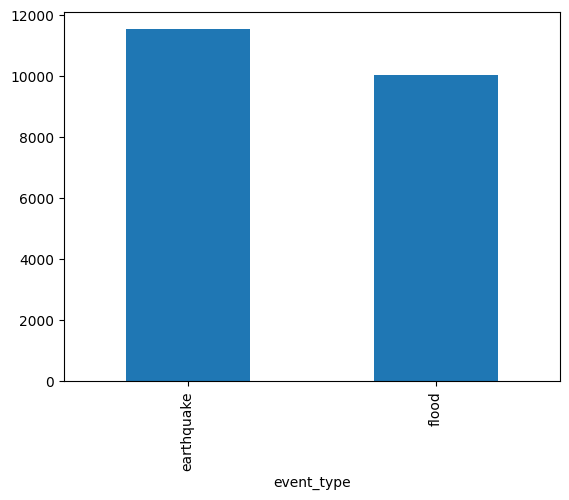

In [24]:
merged_df['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

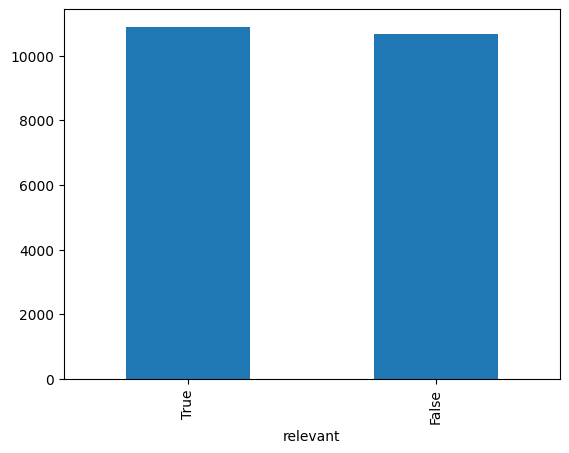

In [25]:
merged_df['relevant'].value_counts().plot(kind='bar')